# Digital Twin for HAADF and EDS



In [1]:
import sys
from pathlib import Path

# For resolving ModuleNotFoundErrors
notebook_dir = Path.cwd()
parent_dir = notebook_dir.parent.resolve()
if str(parent_dir) not in sys.path:
    sys.path.insert(0, str(parent_dir))

import json

import numpy as np
import matplotlib.pyplot as plt
from asyncroscopy.ThermoHaadfEdsTwin import ThermoHaadfEdsTwin
from tango.test_context import MultiDeviceTestContext
from asyncroscopy.detectors.HAADF import HAADF
from asyncroscopy.detectors.EDS import EDS

import tango

## Setup Tango Test Context

We spin up a local Tango server in the notebook process.

In [2]:
devices_info = [
    {
        "class": HAADF,
        "devices": [
            {
                "name": "test/nodb/haadf",
                "properties": {},
            }
        ],
    },

    {
        "class": EDS,
        "devices": [
            {
                "name": "test/nodb/eds",
                "properties": {},
            }
        ],
    },
    
    {
        "class": ThermoHaadfEdsTwin,
        "devices": [
            {
                "name": "test/nodb/twin",
                "properties": {
                    "haadf_device_address": "test/nodb/haadf",
                    "eds_device_address": "test/nodb/eds",
                },
            }
        ],
    },
]

ctx = MultiDeviceTestContext(devices_info, process=False)
ctx.start()

haadf_proxy = tango.DeviceProxy("test/nodb/haadf")
mic_proxy = tango.DeviceProxy("test/nodb/twin")
eds_proxy = tango.DeviceProxy("test/nodb/eds")

print(f"Device state: {haadf_proxy.state()}")
print(f"Device state: {eds_proxy.state()}")

# print(f"Manufacturer: {haadf_proxy.manufacturer}")

print(f"Device state: {mic_proxy.state()}")
print(f"Manufacturer: {mic_proxy.manufacturer}")

2026-03-19T13:40:46,400774-0400 INFO (HAADF.py:57) test/nodb/haadf HAADF device initialised
2026-03-19T13:40:46,401418-0400 INFO (EDS.py:49) test/nodb/eds EDS device initialised
{'haadf': 'test/nodb/haadf', 'AdvancedAcquistion': None, 'eds': 'test/nodb/eds', 'stage': None, 'scan': None}
2026-03-19T13:40:46,402623-0400 INFO (ThermoHaadfEdsTwin.py:92) test/nodb/twin Connected to detector proxy: haadf @ test/nodb/haadf
2026-03-19T13:40:46,402644-0400 INFO (ThermoHaadfEdsTwin.py:88) test/nodb/twin Skipping AdvancedAcquistion: no address configured
2026-03-19T13:40:46,402716-0400 INFO (ThermoHaadfEdsTwin.py:92) test/nodb/twin Connected to detector proxy: eds @ test/nodb/eds
2026-03-19T13:40:46,402727-0400 INFO (ThermoHaadfEdsTwin.py:88) test/nodb/twin Skipping stage: no address configured
2026-03-19T13:40:46,402734-0400 INFO (ThermoHaadfEdsTwin.py:88) test/nodb/twin Skipping scan: no address configured
Ready to accept request
Device state: ON
Device state: ON
Device state: ON
Manufacturer: 

In [8]:
print('--- HAADF attributes ---')
for attr in haadf_proxy.get_attribute_list():
    print(f'  {attr}')

print('--- EDS attributes ---')
for attr in eds_proxy.get_attribute_list():
    print(f'  {attr}')

print('\n--- Microscope commands ---')
for cmd in mic_proxy.get_command_list():
    print(f'  {cmd}')

--- HAADF attributes ---
  dwell_time
  imsize
  State
  Status
--- EDS attributes ---
  exposure_time
  State
  Status

--- Microscope commands ---
  Connect
  Disconnect
  Init
  State
  Status
  blank_beam
  get_image
  get_image_data_cached
  get_images
  get_scanned_image
  get_spectrum
  get_stage
  move_stage
  place_beam
  set_fov
  unblank_beam


## Acquire Simulated Image

Acquire an image from the HAADF detector and visualize it.

Metadata: {'detector': 'haadf', 'shape': [512, 512], 'dtype': 'uint16', 'dwell_time': 1e-06, 'timestamp': 1773942047.080686}


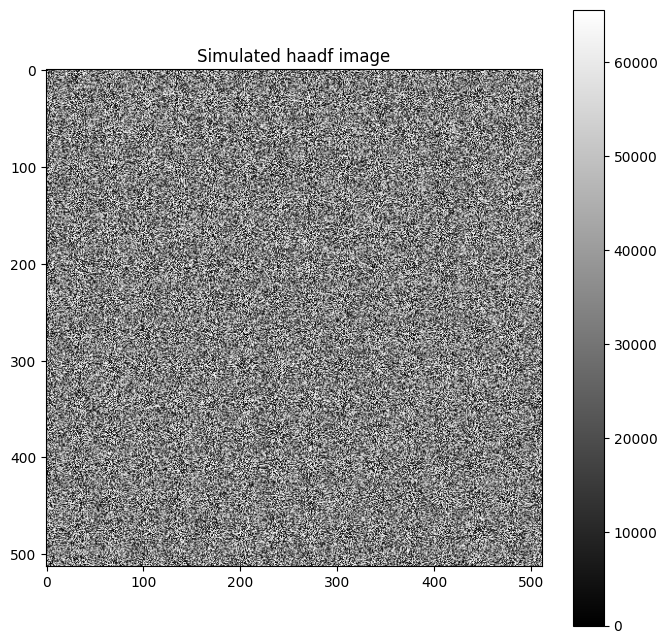

In [3]:
json_meta, raw_bytes = mic_proxy.get_image("haadf")
meta = json.loads(json_meta)
print(f"Metadata: {meta}")

image = np.frombuffer(raw_bytes, dtype=meta["dtype"]).reshape(meta["shape"])

plt.figure(figsize=(8, 8))
plt.imshow(image, cmap='gray')
plt.title(f"Simulated {meta['detector']} image")
plt.colorbar()
plt.show()

In [15]:
mic_proxy.place_beam([0.5, 0.5])

## Query beam

In [16]:
beam_pos = mic_proxy.beam_pos

Metadata: {'detector': 'haadf', 'shape': [512, 512], 'dtype': 'uint16', 'dwell_time': 1e-06, 'timestamp': 1773942362.987052}


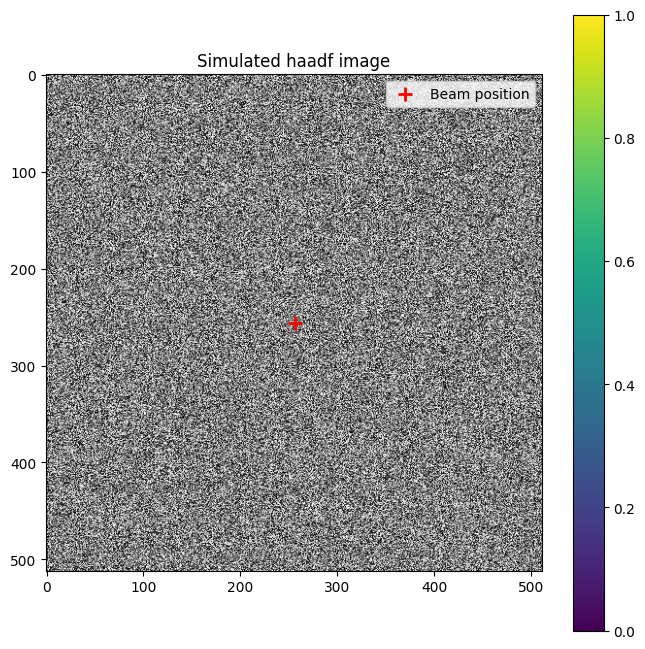

In [17]:
json_meta, raw_bytes = mic_proxy.get_image("haadf")
meta = json.loads(json_meta)
print(f"Metadata: {meta}")

image = np.frombuffer(raw_bytes, dtype=meta["dtype"]).reshape(meta["shape"])

# Read beam position and scale from fractional [0,1] to pixel coordinates
beam_pos = mic_proxy.beam_pos                  # returns [x, y] in [0.0, 1.0]
h, w = image.shape
beam_x_px = beam_pos[0] * w                   # fractional → pixel
beam_y_px = beam_pos[1] * h

plt.figure(figsize=(8, 8))
plt.imshow(image, cmap='gray')

# Overlay beam position
plt.scatter(beam_x_px, beam_y_px, 
            color='red', s=100, marker='+',
            linewidths=2, label="Beam position")

plt.title(f"Simulated {meta['detector']} image")
plt.legend(loc='upper right')
plt.colorbar()
plt.show()

## EDS

In [4]:
json_meta, raw_bytes = mic_proxy.get_spectrum('eds')

metadata  = dict(json.loads(json_meta))
image = np.frombuffer(raw_bytes, dtype=metadata['dtype'])

print('Metadata:', metadata)
print('Image shape:', image.shape)
print('Image dtype:', image.dtype)

Metadata: {'detector': 'eds', 'dtype': 'float64', 'dwell_time': 1.0, 'timestamp': 1773942047.74927}
Image shape: (20,)
Image dtype: float64


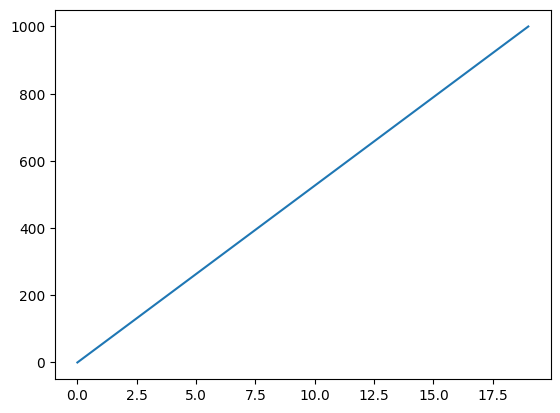

In [5]:
plt.figure()
plt.plot(image)